# Golf Swing Logger — Practice vs Real Putts

Comparing accelerometer data from the Garmin FR 255 SwingLogger app.
- **Practice.fit** — 12 practice swings (no ball)
- **Real.fit** — 12 real putts (with ball)

In [1]:
import fitparse
import pandas as pd
import matplotlib
matplotlib.use('agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display

def load_fit(path):
    fitfile = fitparse.FitFile(path)
    records = []
    for record in fitfile.get_messages("record"):
        row = {}
        for field in record.fields:
            row[field.name] = field.value
        records.append(row)
    df = pd.DataFrame(records)
    df['elapsed'] = range(len(df))
    return df

def show_plot(fig, filename):
    fig.savefig(filename, dpi=150, bbox_inches='tight')
    plt.close(fig)
    display(Image(filename=filename))

practice = load_fit("Practice.fit")
real = load_fit("Real.fit")

print(f"Practice: {len(practice)} records, {len(practice)} seconds")
print(f"Real:     {len(real)} records, {len(real)} seconds")

Practice: 63 records, 63 seconds
Real:     62 records, 62 seconds


## Side-by-Side Comparison: Peak Magnitude Over Time

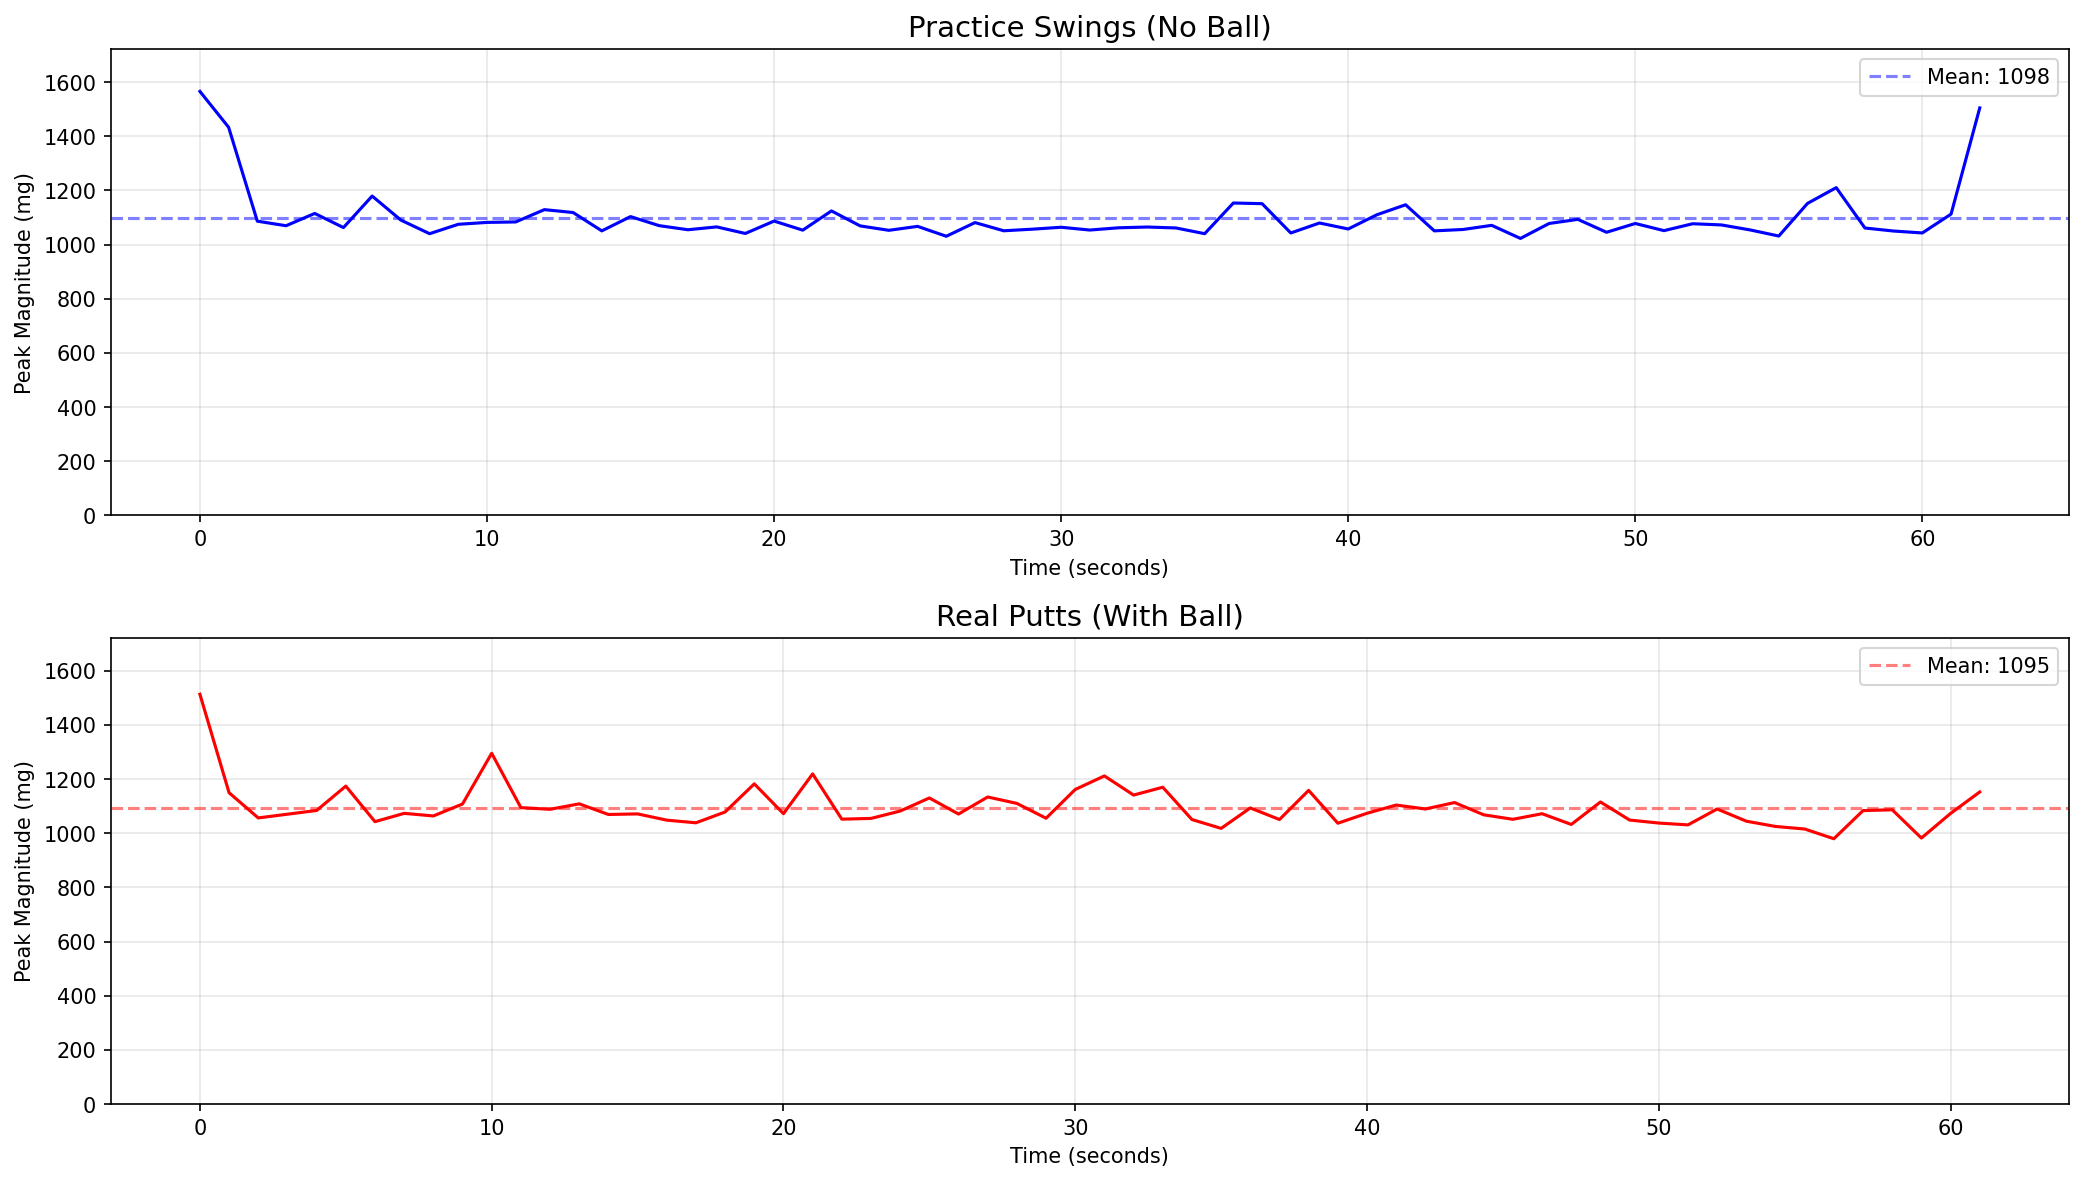

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

axes[0].plot(practice['elapsed'], practice['peak_magnitude'], color='blue', linewidth=1.5)
axes[0].set_title('Practice Swings (No Ball)', fontsize=14)
axes[0].set_ylabel('Peak Magnitude (mg)')
axes[0].set_xlabel('Time (seconds)')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=practice['peak_magnitude'].mean(), color='blue', linestyle='--', alpha=0.5, label=f"Mean: {practice['peak_magnitude'].mean():.0f}")
axes[0].legend()

axes[1].plot(real['elapsed'], real['peak_magnitude'], color='red', linewidth=1.5)
axes[1].set_title('Real Putts (With Ball)', fontsize=14)
axes[1].set_ylabel('Peak Magnitude (mg)')
axes[1].set_xlabel('Time (seconds)')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=real['peak_magnitude'].mean(), color='red', linestyle='--', alpha=0.5, label=f"Mean: {real['peak_magnitude'].mean():.0f}")
axes[1].legend()

ymax = max(practice['peak_magnitude'].max(), real['peak_magnitude'].max()) * 1.1
axes[0].set_ylim(0, ymax)
axes[1].set_ylim(0, ymax)

plt.tight_layout()
show_plot(fig, 'comparison_magnitude.png')

## Overlay: Practice vs Real on Same Plot

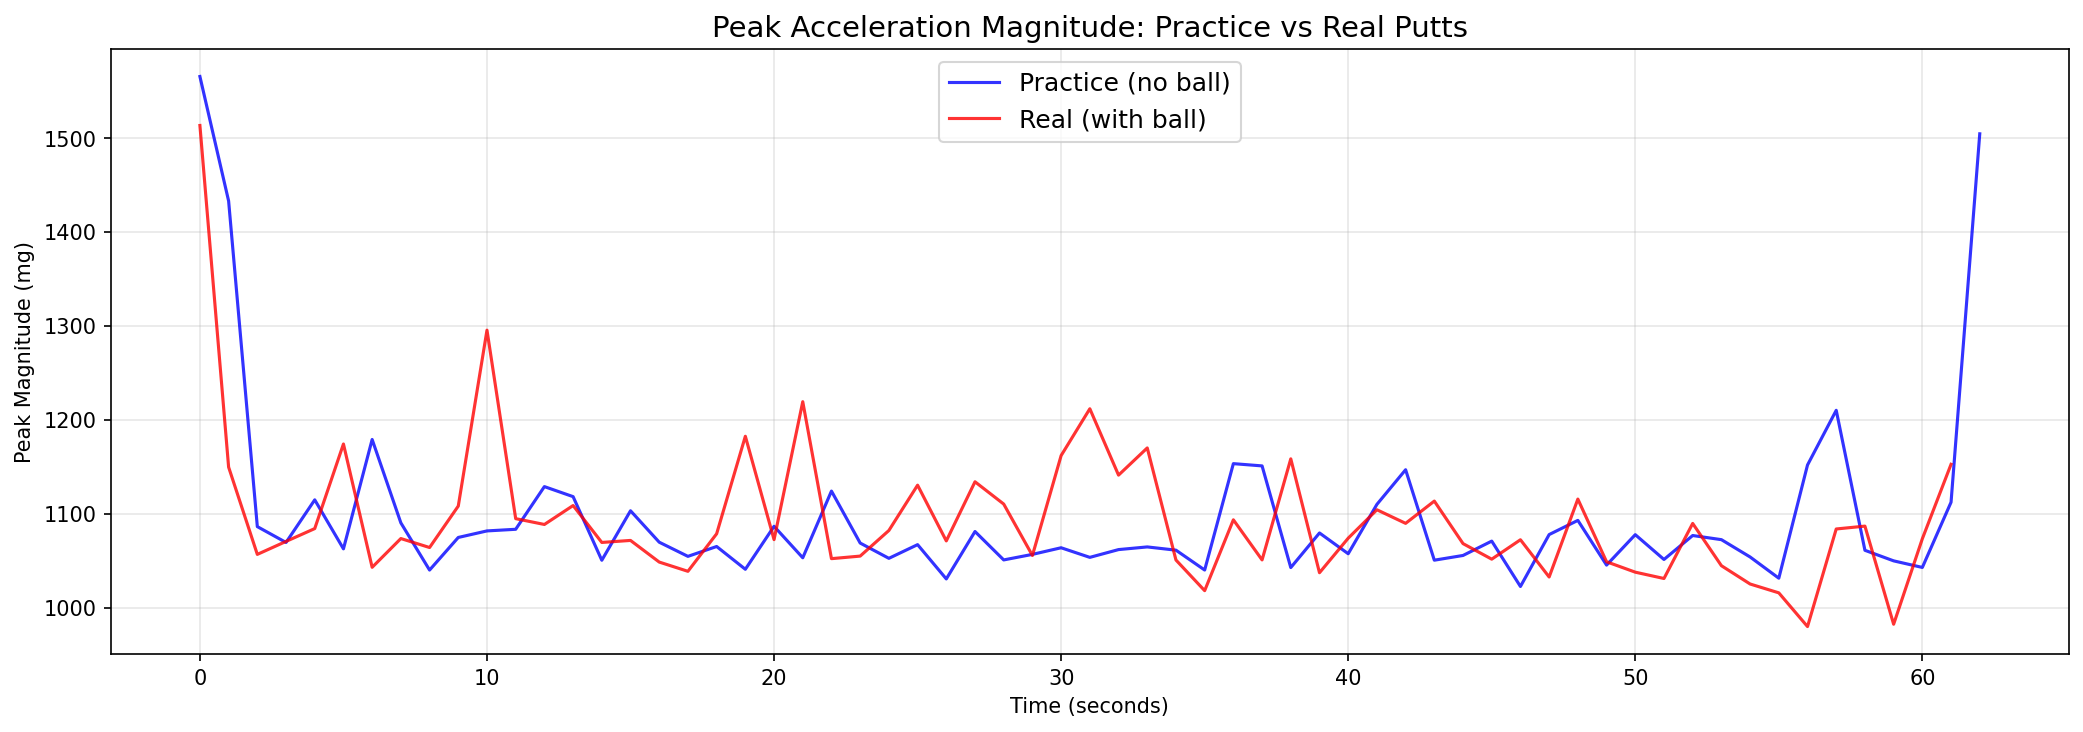

In [3]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(practice['elapsed'], practice['peak_magnitude'], color='blue', linewidth=1.5, alpha=0.8, label='Practice (no ball)')
ax.plot(real['elapsed'], real['peak_magnitude'], color='red', linewidth=1.5, alpha=0.8, label='Real (with ball)')
ax.set_title('Peak Acceleration Magnitude: Practice vs Real Putts', fontsize=14)
ax.set_ylabel('Peak Magnitude (mg)')
ax.set_xlabel('Time (seconds)')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
show_plot(fig, 'overlay_comparison.png')

## X/Y/Z Axis Breakdown

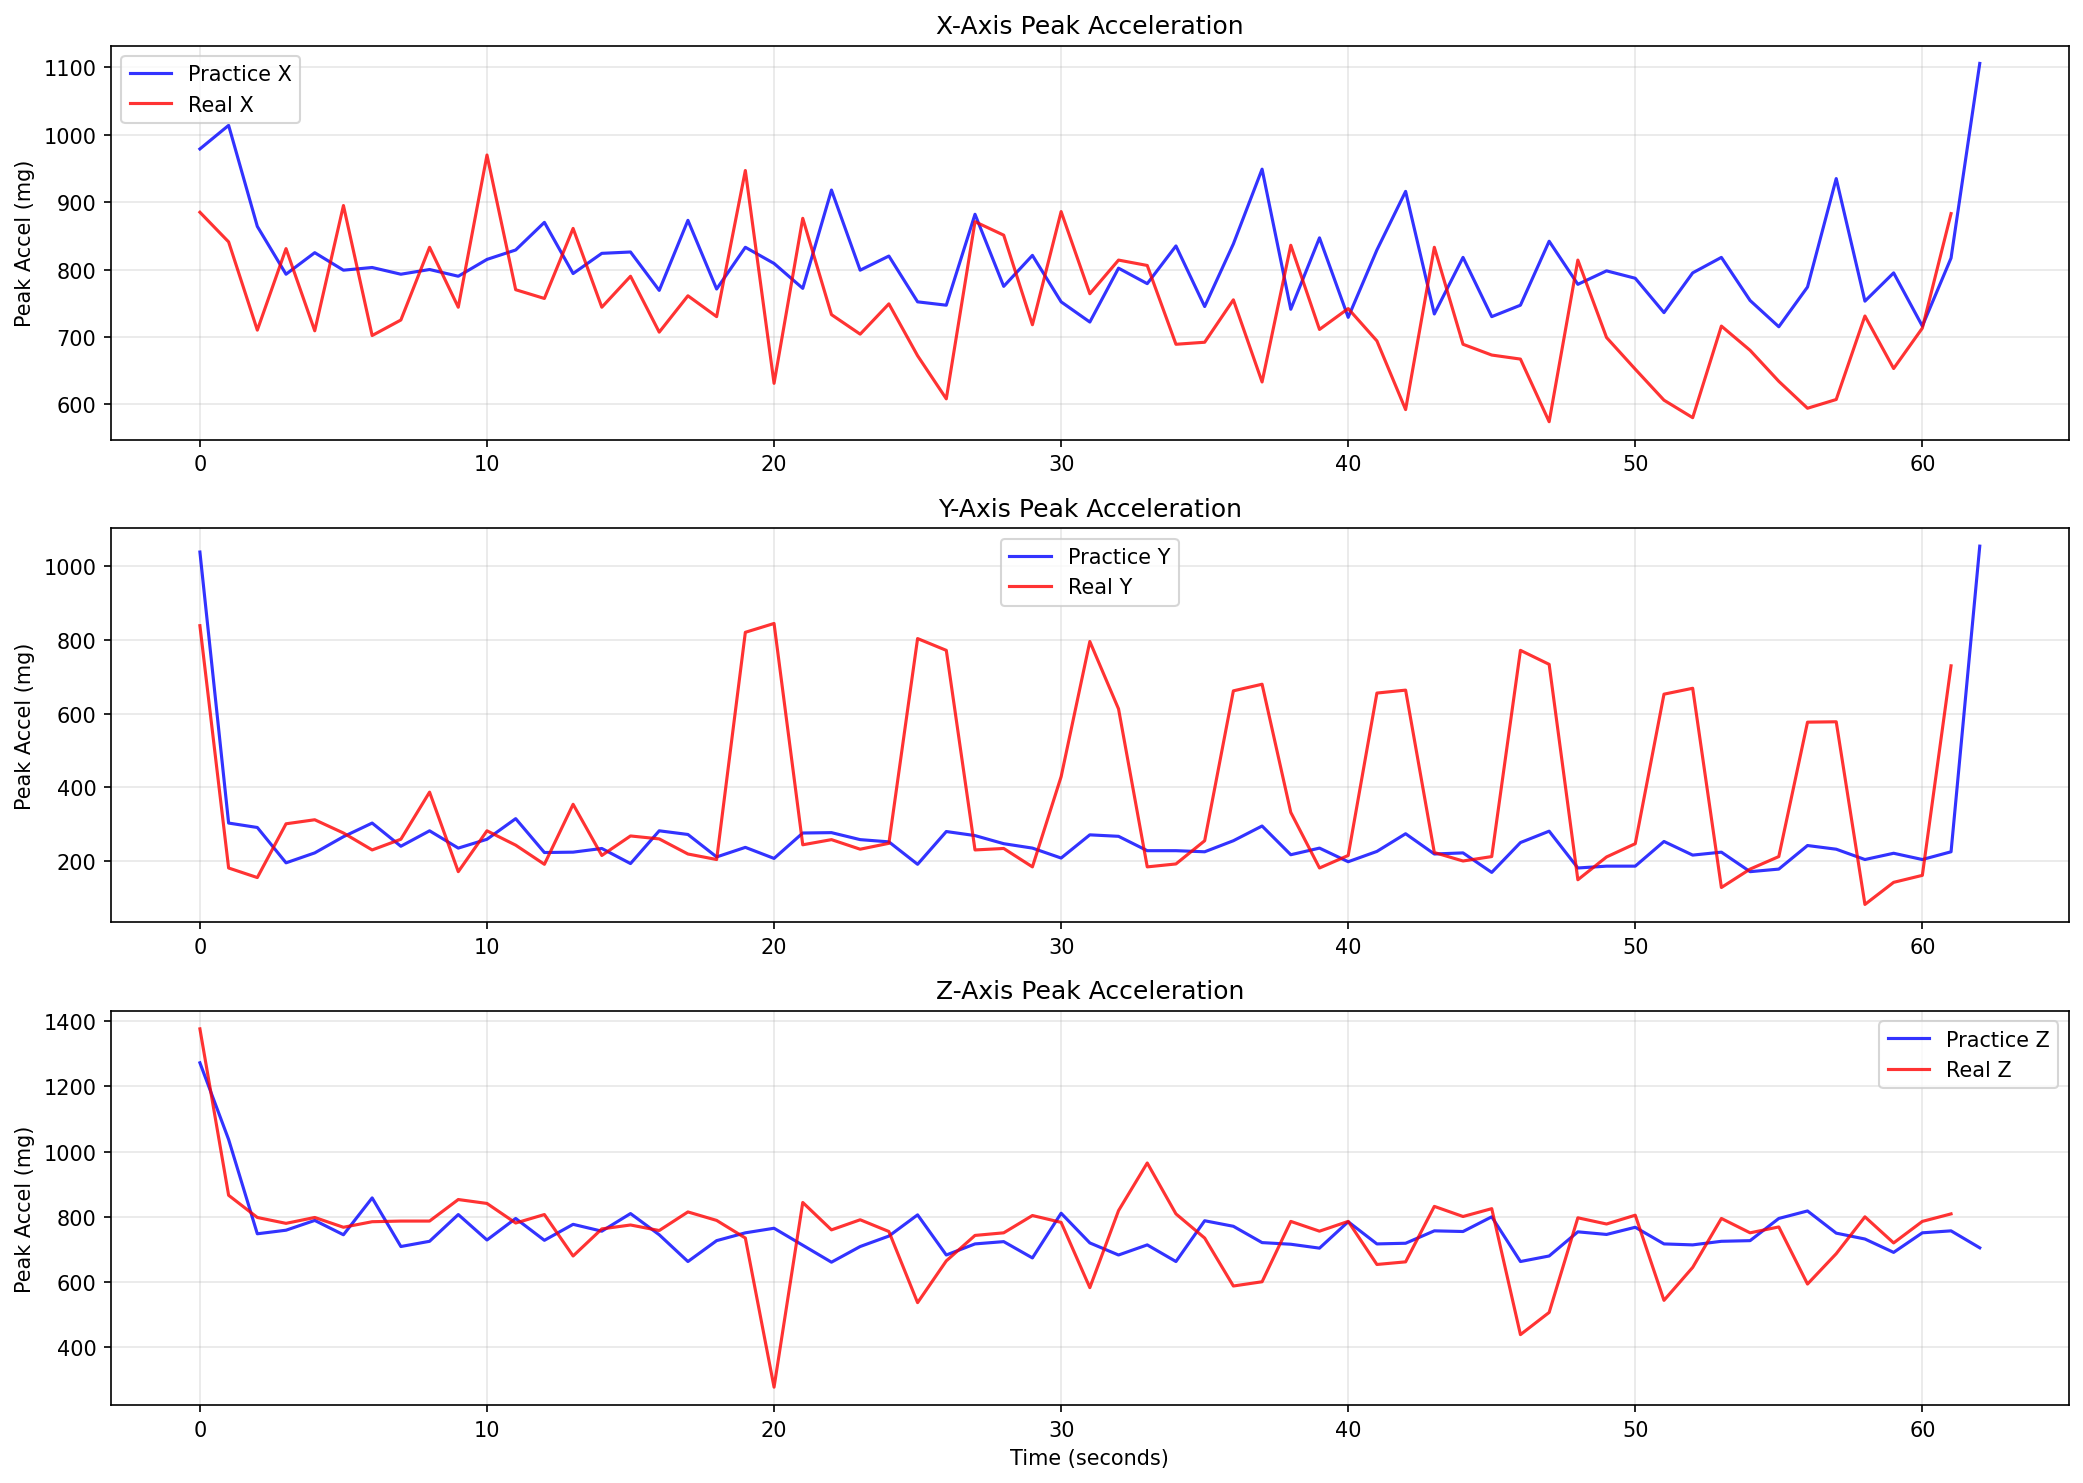

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

for i, axis in enumerate(['peak_accel_x', 'peak_accel_y', 'peak_accel_z']):
    label = axis.split('_')[-1].upper()
    axes[i].plot(practice['elapsed'], practice[axis], color='blue', alpha=0.8, label=f'Practice {label}')
    axes[i].plot(real['elapsed'], real[axis], color='red', alpha=0.8, label=f'Real {label}')
    axes[i].set_title(f'{label}-Axis Peak Acceleration', fontsize=12)
    axes[i].set_ylabel('Peak Accel (mg)')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

axes[2].set_xlabel('Time (seconds)')
plt.tight_layout()
show_plot(fig, 'xyz_comparison.png')

## Statistical Summary

In [6]:
accel_cols = ['peak_accel_x', 'peak_accel_y', 'peak_accel_z', 'peak_magnitude']

print("=" * 60)
print("PRACTICE SWINGS (no ball)")
print("=" * 60)
print(practice[accel_cols].describe().round(1))

print("\n" + "=" * 60)
print("REAL PUTTS (with ball)")
print("=" * 60)
print(real[accel_cols].describe().round(1))

print("\n" + "=" * 60)
print("DIFFERENCE (Real - Practice)")
print("=" * 60)
diff = real[accel_cols].mean() - practice[accel_cols].mean()
print(diff.round(1))
print(f"\nMagnitude difference: {diff['peak_magnitude']:.1f} mg ({diff['peak_magnitude']/practice['peak_magnitude'].mean()*100:.1f}%)")

PRACTICE SWINGS (no ball)
       peak_accel_x  peak_accel_y  peak_accel_z  peak_magnitude
count          63.0          63.0          63.0            63.0
mean          812.6         262.9         753.0          1098.1
std            72.8         147.4          87.4            98.8
min           715.0         169.0         661.0          1022.5
25%           770.0         216.5         715.0          1053.3
50%           799.0         235.0         741.0          1069.4
75%           831.0         270.0         769.5          1098.0
max          1106.0        1055.0        1272.0          1565.5

REAL PUTTS (with ball)
       peak_accel_x  peak_accel_y  peak_accel_z  peak_magnitude
count          62.0          62.0          62.0            62.0
mean          740.9         369.9         749.7          1094.6
std            94.8         233.8         137.9            78.4
min           574.0          82.0         278.0           979.8
25%           682.2         205.8         723.8       

## Stroke Detection — Finding the Spikes

In [7]:
from scipy.signal import find_peaks

# Try different thresholds to find 12 strokes
for label, df, color in [('Practice', practice, 'blue'), ('Real', real, 'red')]:
    mag = df['peak_magnitude'].values
    
    # Find peaks with minimum distance of 3 seconds between strokes
    # and prominence to filter out noise
    peaks, properties = find_peaks(mag, distance=3, prominence=50)
    
    print(f"\n{label}: Found {len(peaks)} peaks")
    print(f"  Peak times (seconds): {list(peaks)}")
    print(f"  Peak magnitudes: {[round(mag[p]) for p in peaks]}")
    print(f"  Mean peak magnitude: {mag[peaks].mean():.0f} mg")
    print(f"  Std peak magnitude: {mag[peaks].std():.0f} mg")


Practice: Found 8 peaks
  Peak times (seconds): [np.int64(6), np.int64(12), np.int64(15), np.int64(22), np.int64(36), np.int64(42), np.int64(48), np.int64(57)]
  Peak magnitudes: [1179, 1129, 1103, 1124, 1153, 1147, 1093, 1210]
  Mean peak magnitude: 1142 mg
  Std peak magnitude: 36 mg

Real: Found 10 peaks
  Peak times (seconds): [np.int64(5), np.int64(10), np.int64(21), np.int64(27), np.int64(31), np.int64(38), np.int64(43), np.int64(48), np.int64(52), np.int64(58)]
  Peak magnitudes: [1174, 1295, 1219, 1134, 1212, 1158, 1113, 1116, 1090, 1087]
  Mean peak magnitude: 1160 mg
  Std peak magnitude: 63 mg


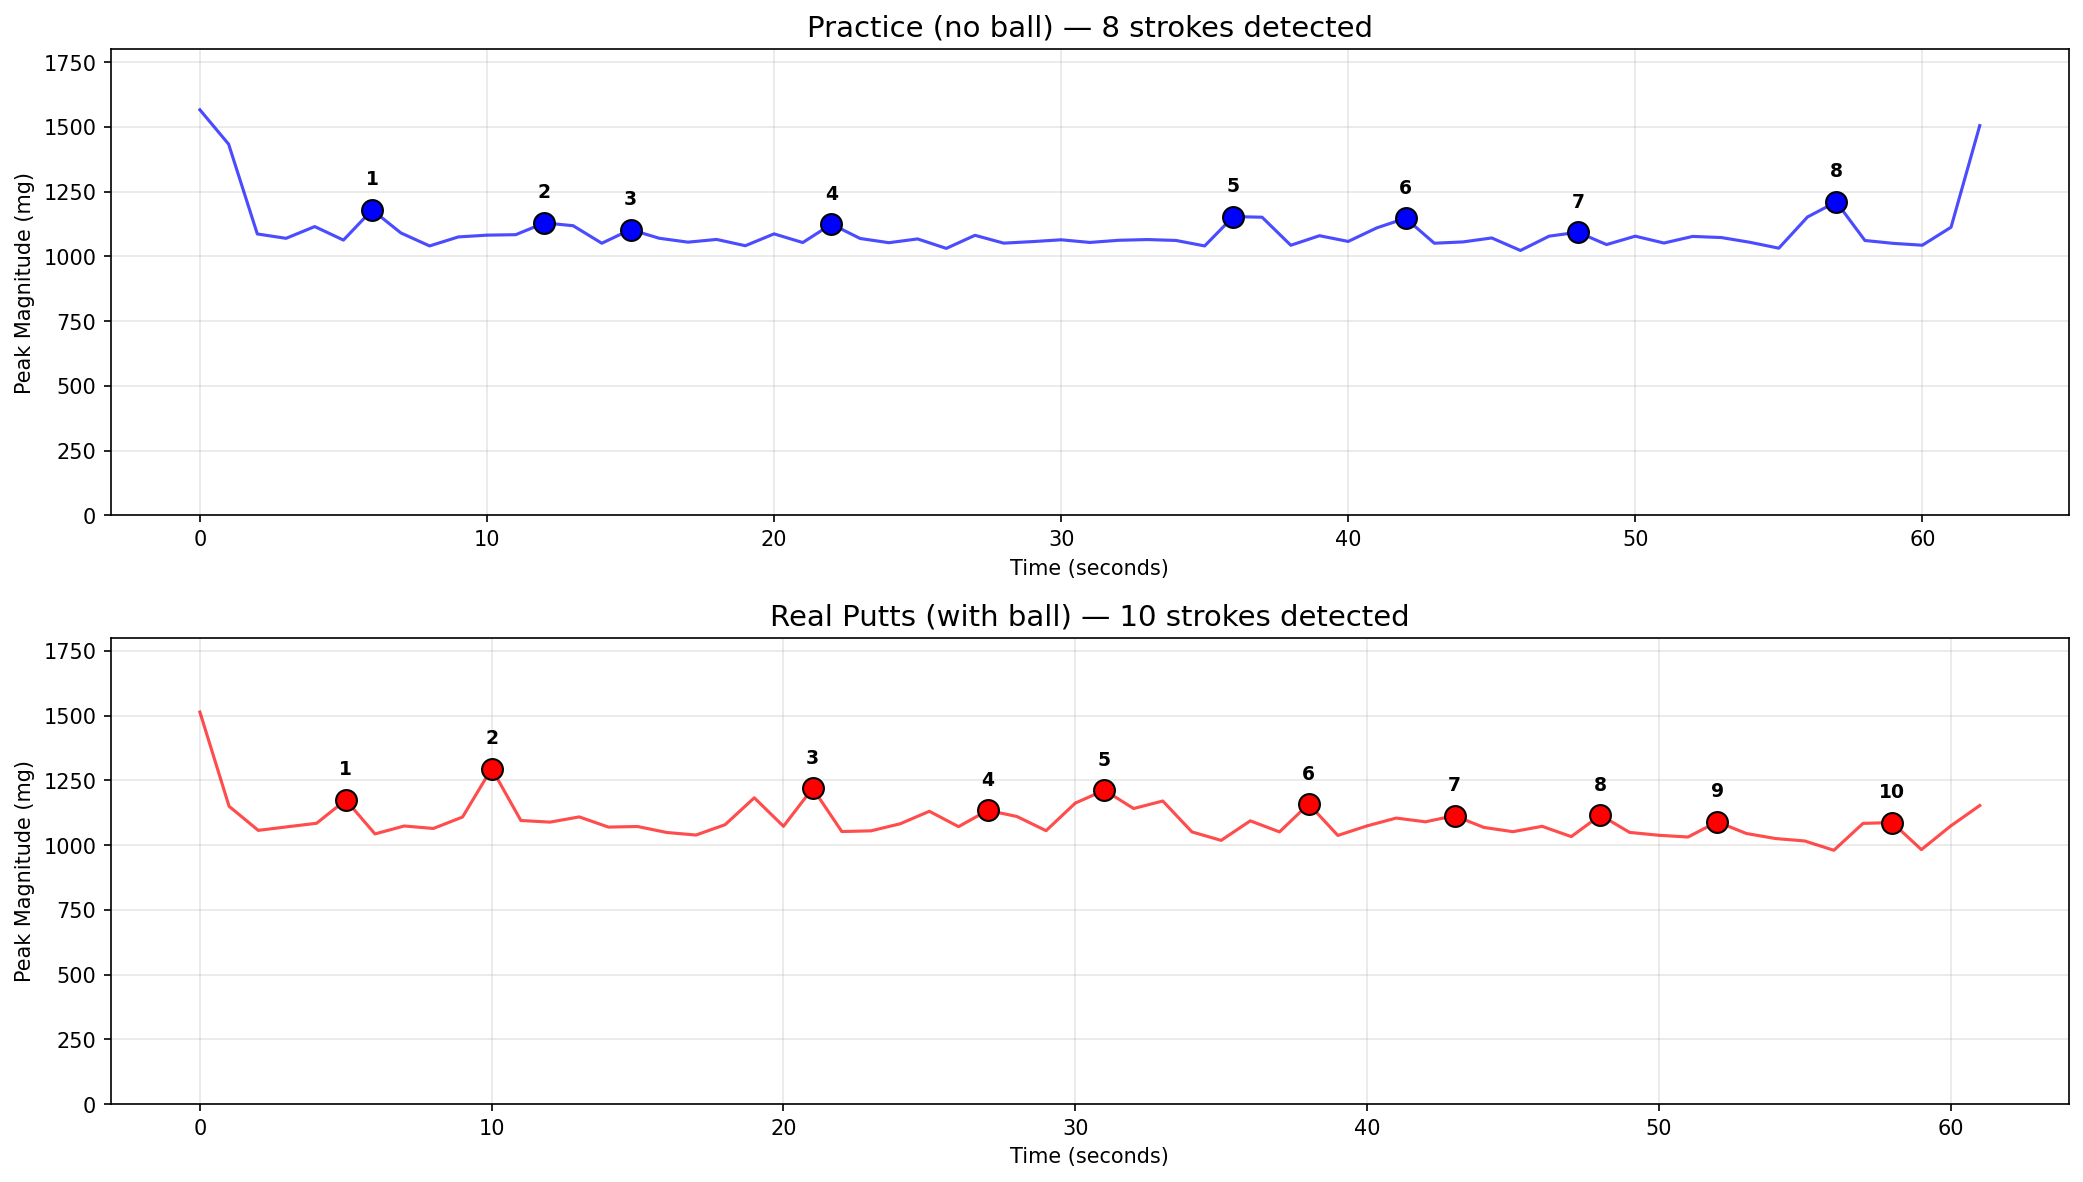

In [8]:
# Plot with detected strokes highlighted
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for i, (label, df, color) in enumerate([('Practice (no ball)', practice, 'blue'), ('Real Putts (with ball)', real, 'red')]):
    mag = df['peak_magnitude'].values
    elapsed = df['elapsed'].values
    peaks, _ = find_peaks(mag, distance=3, prominence=50)
    
    axes[i].plot(elapsed, mag, color=color, linewidth=1.5, alpha=0.7)
    axes[i].scatter(elapsed[peaks], mag[peaks], color=color, s=100, zorder=5, edgecolors='black', linewidth=1)
    
    # Number each detected stroke
    for j, p in enumerate(peaks):
        axes[i].annotate(f'{j+1}', (elapsed[p], mag[p]), textcoords="offset points", 
                        xytext=(0, 12), ha='center', fontsize=9, fontweight='bold')
    
    axes[i].set_title(f'{label} — {len(peaks)} strokes detected', fontsize=14)
    axes[i].set_ylabel('Peak Magnitude (mg)')
    axes[i].set_xlabel('Time (seconds)')
    axes[i].grid(True, alpha=0.3)

ymax = max(practice['peak_magnitude'].max(), real['peak_magnitude'].max()) * 1.15
axes[0].set_ylim(0, ymax)
axes[1].set_ylim(0, ymax)

plt.tight_layout()
show_plot(fig, 'stroke_detection.png')

## Stroke-by-Stroke Comparison: Practice vs Real

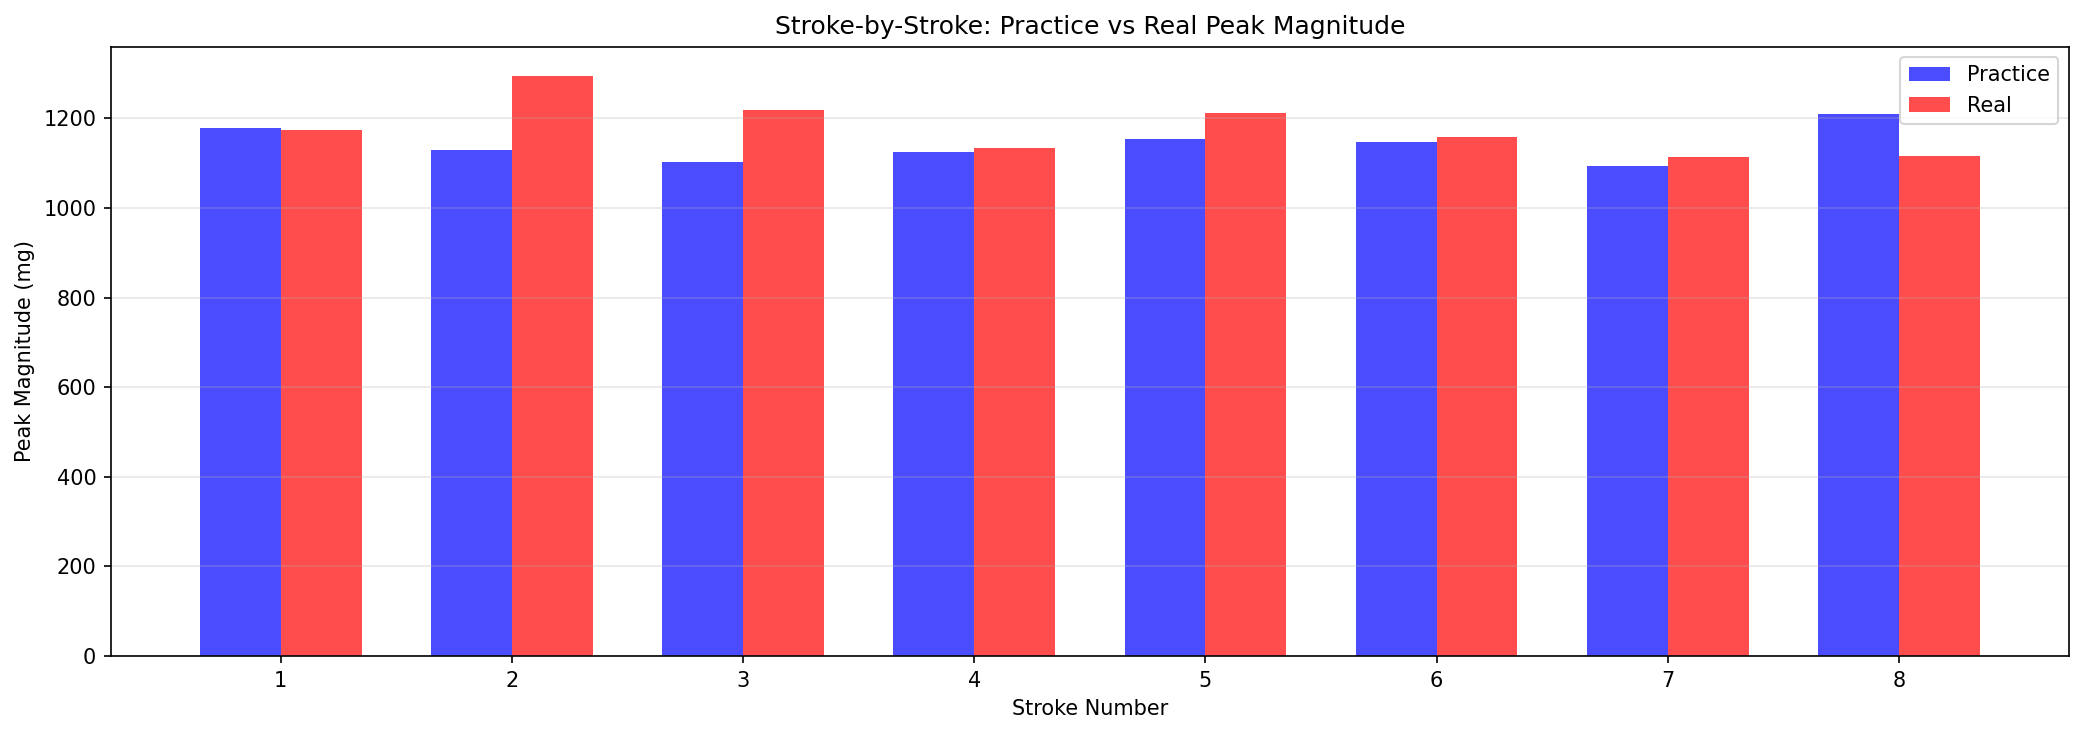


Practice strokes: 8
Real strokes: 10

Practice mean peak: 1142 mg (std: 36)
Real mean peak:     1160 mg (std: 63)

Difference: 18 mg (1.5%)


In [9]:
# Compare detected stroke magnitudes side by side
practice_peaks, _ = find_peaks(practice['peak_magnitude'].values, distance=3, prominence=50)
real_peaks, _ = find_peaks(real['peak_magnitude'].values, distance=3, prominence=50)

practice_mags = practice['peak_magnitude'].values[practice_peaks]
real_mags = real['peak_magnitude'].values[real_peaks]

# Bar chart comparison
fig, ax = plt.subplots(figsize=(14, 5))

n_strokes = min(len(practice_mags), len(real_mags))
x = range(1, n_strokes + 1)
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], practice_mags[:n_strokes], width, label='Practice', color='blue', alpha=0.7)
bars2 = ax.bar([i + width/2 for i in x], real_mags[:n_strokes], width, label='Real', color='red', alpha=0.7)

ax.set_xlabel('Stroke Number')
ax.set_ylabel('Peak Magnitude (mg)')
ax.set_title('Stroke-by-Stroke: Practice vs Real Peak Magnitude')
ax.set_xticks(list(x))
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
show_plot(fig, 'stroke_comparison.png')

# Print summary
print(f"\nPractice strokes: {len(practice_mags)}")
print(f"Real strokes: {len(real_mags)}")
print(f"\nPractice mean peak: {practice_mags.mean():.0f} mg (std: {practice_mags.std():.0f})")
print(f"Real mean peak:     {real_mags.mean():.0f} mg (std: {real_mags.std():.0f})")
print(f"\nDifference: {real_mags.mean() - practice_mags.mean():.0f} mg ({(real_mags.mean() - practice_mags.mean())/practice_mags.mean()*100:.1f}%)")